# Лабораторная работа №1

В данной лабораторной работе мы проведем разведочный анализ датасета. Разведочный анализ предполагает предварительный анализ данных и определение общих закономерностей.

Загрузим датасет, содержащийся в модуле sklearn.datasets, и преобразуем его в датафрейм Pandas.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import *
wine = load_wine()

data1 = pd.DataFrame(data= np.c_[wine['data'], wine['target']],
                     columns= wine['feature_names'] + ['target'])

Изучим, из чего состоит исходный объект датасета.

In [3]:
for x in wine:
    print(x)

data
target
frame
target_names
DESCR
feature_names


Получим названия целевых классов.

In [4]:
wine['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

Выведем датафрейм, чтобы ознакомиться с данными в табличной форме.

In [5]:
data1

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2.0


## Текстовое описание набора данных

Датасет описывает различные образцы вина трех разных итальянских производителей с точки зрения химического состава. Описываются 14 признаков (13 - химические параметры) и 178 образцов вина трех типов.

## Характеристики датасета

* alcohol - содержание алкоголя (проценты)
* target - класс производителя, к которому относится вино
* malic_acid - яблочная кислота
* ash - зола
* alcalinity_of_ash - щелочность золы
* magnesium - магний
* total_phenols - общее содержание фенолов
* flavanoids - флавоноиды
* nonflavanoid_phenols - содержание фенолов, не относящихся к классу флавоноидов
* proanthocyanins - содержание проантоциадинов
* color_intensity - насыщенность цвета
* hue - цветовой оттенок
* od280/od315_of_diluted_wines - отношение оптической плотности вина при длине волны 280 нм и 315 нм
* proline - содержание пролина

Выведем типы, к которым принадлежат данные в датасете.

In [6]:
# Список колонок с типами данных
data1.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                          float64
dtype: object

Все признаки представлены как числа с плавающей запятой. Это обосновано во всех случаях, кроме целевого признака - все его значения являются целыми числами.

Соберём описательную статистику по признакам датасета.

In [7]:
data1.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Можно сделать вывод, что пропусков датасет не имеет. Большой диапазон значений имеет содержание яблочной кислоты.
Данные варьируются в разных диапазонах.

# Визуальное исследование датасета

Подключим библиотеку Matplotlib и надстройку над ней Seaborn, чтобы провести визуальное исследование датасета.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

## Диаграмма рассеяния

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Данные могут быть как упорядочены, так и неупорядочены.

<Axes: xlabel='hue', ylabel='od280/od315_of_diluted_wines'>

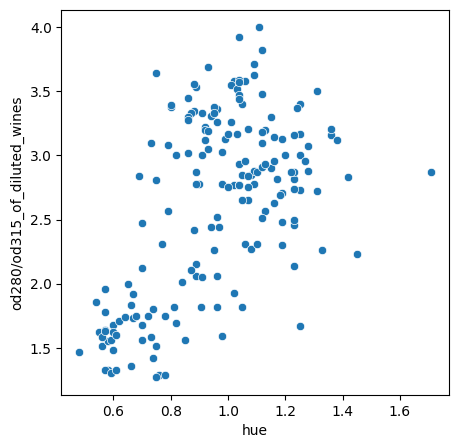

In [9]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.scatterplot(ax=ax, x='hue', y='od280/od315_of_diluted_wines', data=data1)

Соберём данные о распределении каждого признака. Это будет полезным при анализе корреляции.

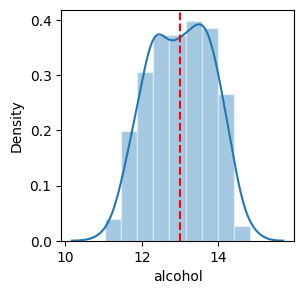

In [33]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['alcohol'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data1['alcohol'].mean(), color='red', linestyle='--')

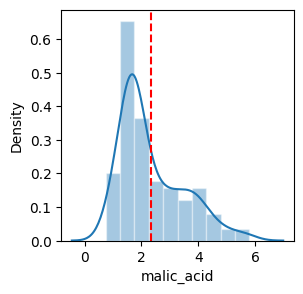

In [32]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['malic_acid'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['malic_acid'].mean(), color='red', linestyle='--')

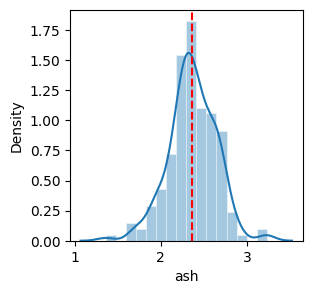

In [34]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['ash'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['ash'].mean(), color='red', linestyle='--')

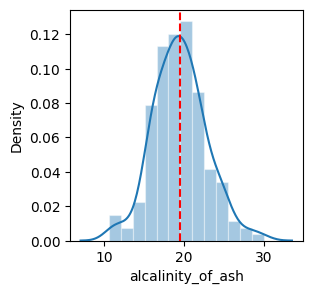

In [35]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['alcalinity_of_ash'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['alcalinity_of_ash'].mean(), color='red', linestyle='--')

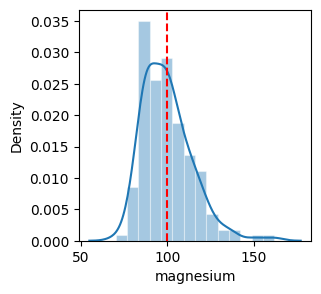

In [36]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['magnesium'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['magnesium'].mean(), color='red', linestyle='--')

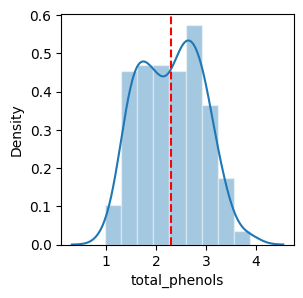

In [37]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['total_phenols'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['total_phenols'].mean(), color='red', linestyle='--')

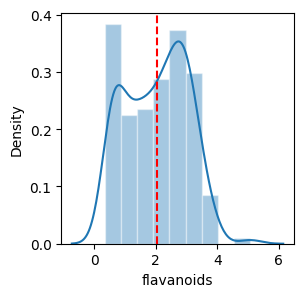

In [38]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['flavanoids'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['flavanoids'].mean(), color='red', linestyle='--')

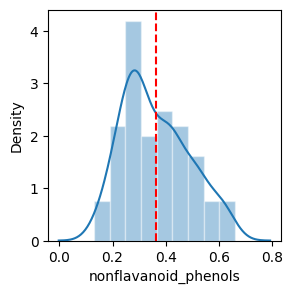

In [39]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['nonflavanoid_phenols'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['nonflavanoid_phenols'].mean(), color='red', linestyle='--')

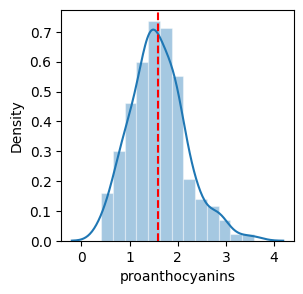

In [40]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['proanthocyanins'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['proanthocyanins'].mean(), color='red', linestyle='--')

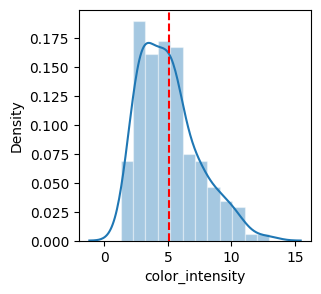

In [41]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['color_intensity'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['color_intensity'].mean(), color='red', linestyle='--')

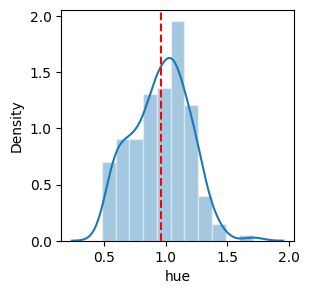

In [42]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['hue'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['hue'].mean(), color='red', linestyle='--')

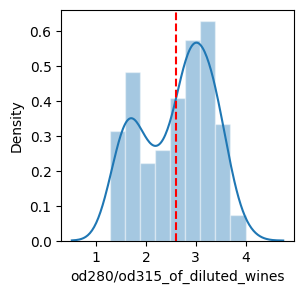

In [43]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['od280/od315_of_diluted_wines'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['od280/od315_of_diluted_wines'].mean(), color='red', linestyle='--')

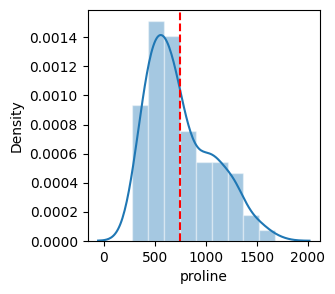

In [44]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data1['proline'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
plt.axvline(data1['proline'].mean(), color='red', linestyle='--')

Можно сделать вывод, что распределение большинства признаков допустимо интерпретировать как нормальное. Тем не менее, следует учесть наличие нескольких пиковых значений (например, у od280/od315_of_diluted_wines) - это может говорить о мультимодальности распределения признака и, следовательно, о наличии нескольких групп (кластеров) данных. Кроме того, ряд признаков (malic_acid, proline, color_intensity) имеют несимметричное распределение, пик которого смещен относительно среднего значения. Скошенность следует принять во внимание. 

# Корреляция признаков

Проверка корреляции признаков позволяет решить две задачи:

*    Понять, какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "target"). Именно эти признаки будут наиболее информативными для моделей машинного обучения. Признаки, которые слабо коррелируют с целевым признаком, можно попробовать исключить из построения модели, иногда это повышает качество модели. Нужно отметить, что некоторые алгоритмы машинного обучения автоматически определяют ценность того или иного признака для построения модели.
*    Понять, какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

Числовая оценка корреляции (взаимосвязи) между признаками осуществима несколькими методами. Например, это метрики:

* Коэффициент Пирсона — для анализа числовых данных с нормальным распределением, при исследовании линейных зависимостей.
* Коэффициент Спирмена — мера ранговой корреляции, считает не сами цифры, а порядок их показателей. Используется для порядковых данных или когда распределение сильно отклоняется от нормального.
* Коэффициент Крамера — показывает, есть ли связь между двумя категориальными переменными: 0 — связи нет, 1 — полная зависимость.
* Коэффициент ранговой корреляции Кендалла — измеряет порядковую связь между двумя измеренными количествами, показывает согласованность в упорядочении пар наблюдений.

Опишем матрицы корреляцим. Учтём, что распределение не всех признаков нормальное.

In [83]:
data1.corr(method='pearson')

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


In [84]:
data1.corr(method='kendall')

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.093844,0.170154,-0.212978,0.250506,0.209099,0.191087,-0.109554,0.133526,0.434353,-0.021717,0.061513,0.449387,-0.238984
malic_acid,0.093844,1.000000,0.158178,0.210119,0.050869,-0.174929,-0.211918,0.175129,-0.168714,0.195607,-0.388707,-0.162909,-0.044660,0.247494
ash,0.170154,0.158178,1.000000,0.258352,0.254246,0.089855,0.049474,0.098937,0.018240,0.187786,-0.037234,-0.006341,0.171574,-0.038085
alcalinity_of_ash,-0.212978,0.210119,0.258352,1.000000,-0.121005,-0.256669,-0.309865,0.278091,-0.171404,-0.057281,-0.239210,-0.226253,-0.313218,0.449402
magnesium,0.250506,0.050869,0.254246,-0.121005,1.000000,0.172195,0.161603,-0.158361,0.117871,0.241781,0.023760,0.034307,0.343016,-0.184992
total_phenols,0.209099,-0.174929,0.089855,-0.256669,0.172195,1.000000,0.701999,-0.310443,0.466517,0.028264,0.289210,0.478267,0.280203,-0.590404
flavanoids,0.191087,-0.211918,0.049474,-0.309865,0.161603,0.701999,1.000000,-0.378099,0.534615,0.028674,0.354372,0.520448,0.263661,-0.725255
nonflavanoid_phenols,-0.109554,0.175129,0.098937,0.278091,-0.158361,-0.310443,-0.378099,1.000000,-0.269189,0.036065,-0.179755,-0.363787,-0.174108,0.379234
proanthocyanins,0.133526,-0.168714,0.018240,-0.171404,0.117871,0.466517,0.534615,-0.269189,1.000000,-0.014962,0.231071,0.369104,0.204172,-0.450225
color_intensity,0.434353,0.195607,0.187786,-0.057281,0.241781,0.028264,0.028674,0.036065,-0.014962,1.000000,-0.291561,-0.206046,0.316632,0.065124


In [85]:
data1.corr(method='spearman')

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.140430,0.243722,-0.306598,0.365503,0.310920,0.294740,-0.162207,0.192734,0.635425,-0.024203,0.103050,0.633580,-0.354167
malic_acid,0.140430,1.000000,0.230674,0.304069,0.080188,-0.280225,-0.325202,0.255236,-0.244825,0.290307,-0.560265,-0.255185,-0.057466,0.346913
ash,0.243722,0.230674,1.000000,0.366374,0.361488,0.132193,0.078796,0.145583,0.024384,0.283047,-0.050183,-0.007500,0.253163,-0.053988
alcalinity_of_ash,-0.306598,0.304069,0.366374,1.000000,-0.169558,-0.376657,-0.443770,0.389390,-0.253695,-0.073776,-0.352507,-0.325890,-0.456090,0.569792
magnesium,0.365503,0.080188,0.361488,-0.169558,1.000000,0.246417,0.233167,-0.236786,0.173647,0.357029,0.036095,0.056963,0.507575,-0.250498
total_phenols,0.310920,-0.280225,0.132193,-0.376657,0.246417,1.000000,0.879404,-0.448013,0.666689,0.011162,0.439457,0.687207,0.419470,-0.726544
flavanoids,0.294740,-0.325202,0.078796,-0.443770,0.233167,0.879404,1.000000,-0.543897,0.730322,-0.042910,0.535430,0.741533,0.429904,-0.854908
nonflavanoid_phenols,-0.162207,0.255236,0.145583,0.389390,-0.236786,-0.448013,-0.543897,1.000000,-0.384629,0.059639,-0.267813,-0.494950,-0.270112,0.474205
proanthocyanins,0.192734,-0.244825,0.024384,-0.253695,0.173647,0.666689,0.730322,-0.384629,1.000000,-0.030947,0.342795,0.554031,0.308249,-0.570648
color_intensity,0.635425,0.290307,0.283047,-0.073776,0.357029,0.011162,-0.042910,0.059639,-0.030947,1.000000,-0.418522,-0.317516,0.457096,0.131170


Ключевая проблема табличной визуализации корреляции признаков нашего датасета - большой размер таблицы. Попробуем вместо числовой репрезентации использовать графическую, в частности - график "тепловая карта" (heatmap).

<Axes: >

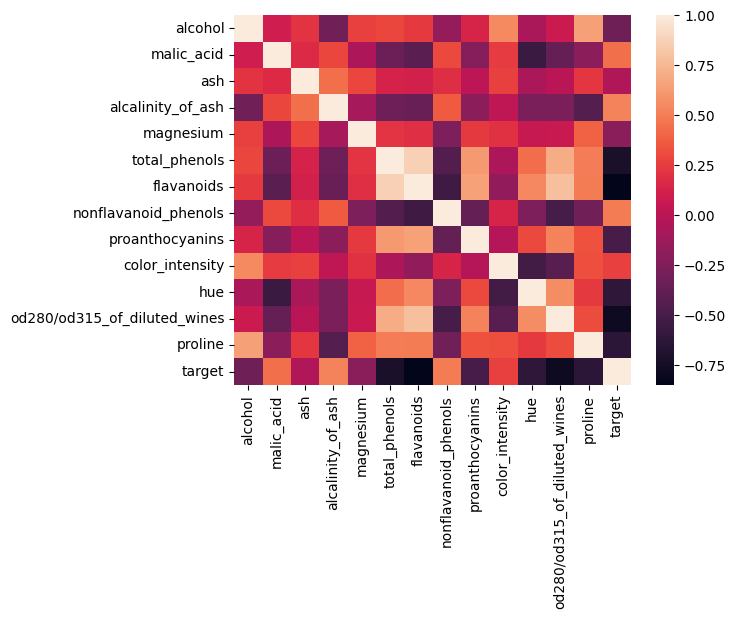

In [87]:
sns.heatmap(data1.corr())

Без числовой информации теряется информативность представления. Попробуем это исправить. Создадим субграфик через Matplotlib, отмасштабируем его, затем через параметр ax впишем матрицу в область субграфика. Через параметр annot в ячейках "тепловой карты" будет выводиться числовое значение коэффициента.

<Axes: >

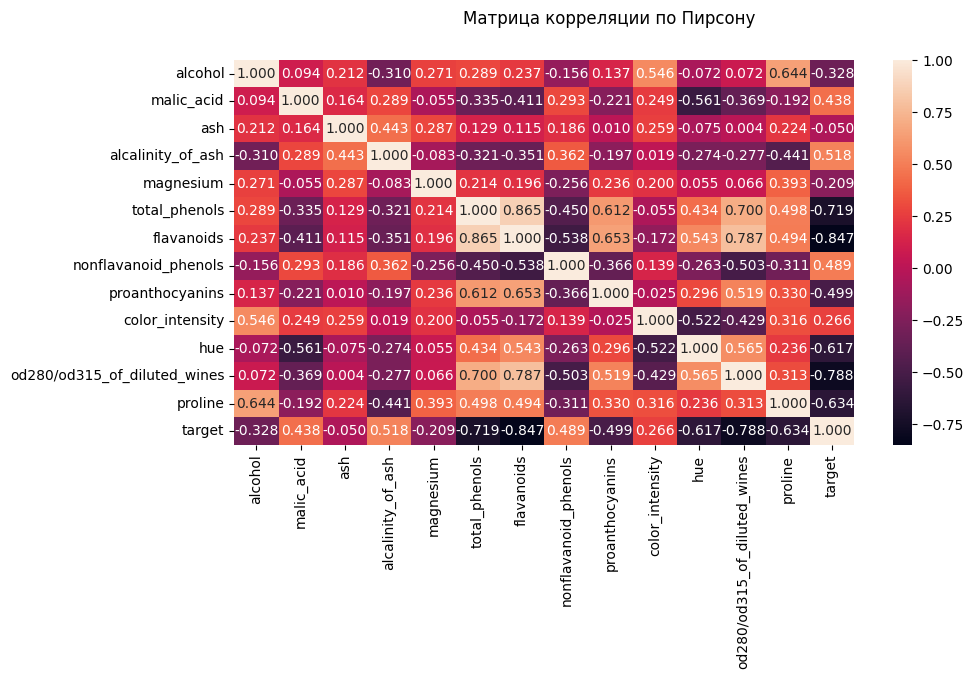

In [89]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Матрица корреляции по Пирсону')
sns.heatmap(data1.corr(), ax=ax, annot=True, fmt='.3f')

Чтобы уменьшить визуальную нагрузку на наблюдателя, сделаем матрицу треугольной, тем самым исключив дублирующиеся данные.

<Axes: >

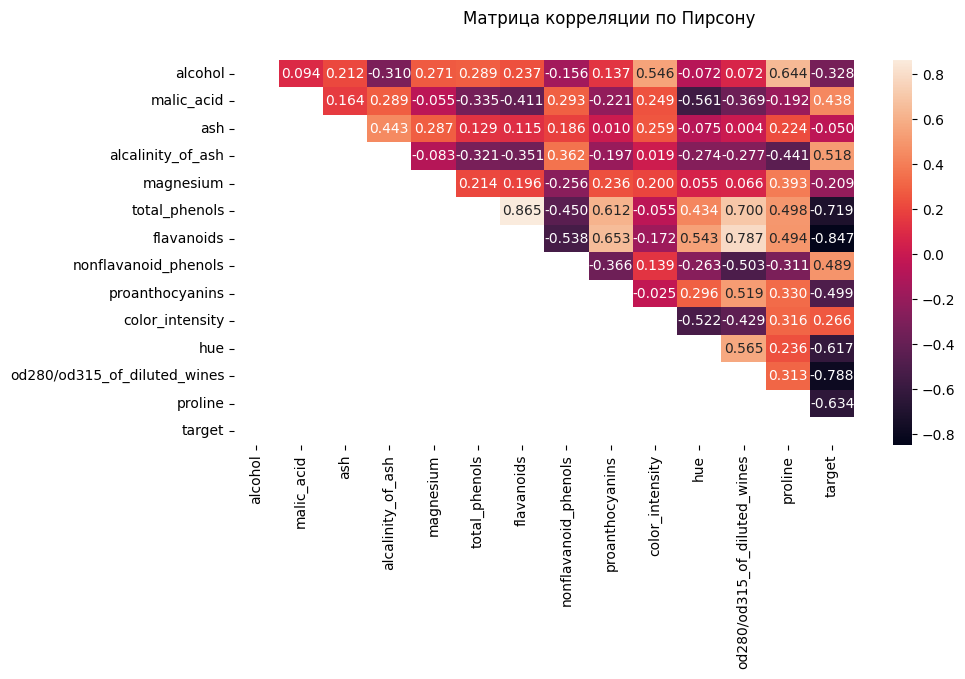

In [91]:
# Треугольный вариант матрицы
mask = np.zeros_like(data1.corr(), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Матрица корреляции по Пирсону')
sns.heatmap(data1.corr(), mask=mask, annot=True, fmt='.3f')

Мы избавились от лишней информации. Теперь можно аналогичным образом построить "тепловые карты" для других коэффициентов корреляции и сделать выводы.

<Axes: >

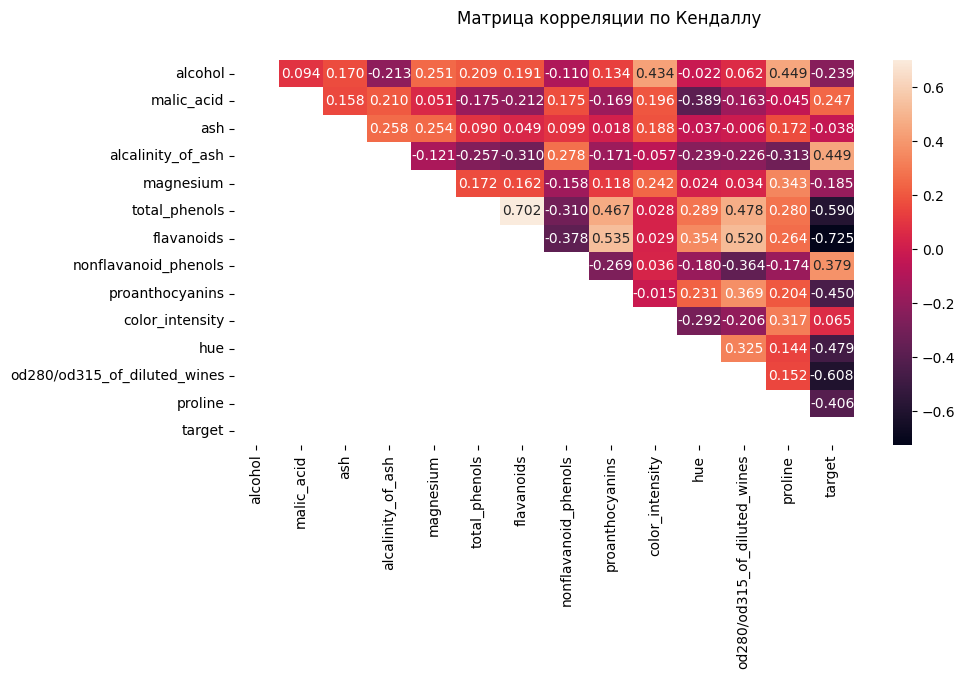

In [93]:
mask = np.zeros_like(data1.corr(method='kendall'), dtype=np.bool)
mask[np.tril_indices_from(mask)] = True
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Матрица корреляции по Кендаллу')
sns.heatmap(data1.corr(method='kendall'), mask=mask, annot=True, fmt='.3f')

<Axes: >

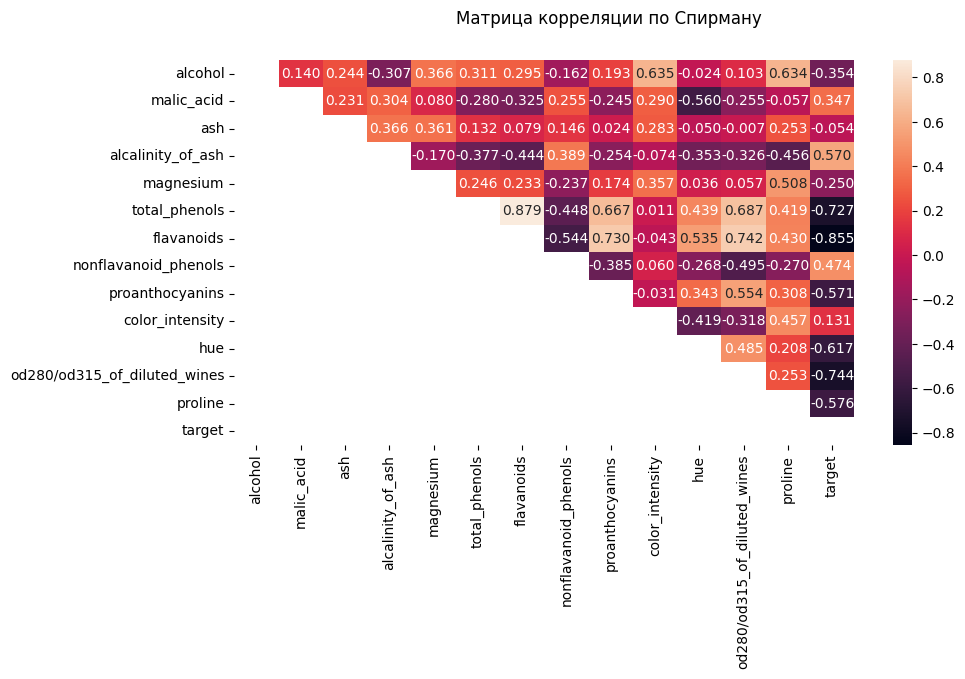

In [94]:
mask = np.zeros_like(data1.corr(method='spearman'), dtype=np.bool)
mask[np.tril_indices_from(mask)] = True
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Матрица корреляции по Спирману')
sns.heatmap(data1.corr(method='spearman'), mask=mask, annot=True, fmt='.3f')

На основе корреляционных матриц можно сделать следующие выводы:

* Целевой признак показывает сильную отрицательную (-0,7 &ndash; -0,9) корреляцию с содержанием флавоноидов.
* Целевой признак показывает как минимум заметную отрицательную (-0,5 &ndash; -0,7)  корреляцию с содержанием пролинов.
* Целевой признак практически не коррелирует с признаком ash.
* С остальными признаками целевой имеет как минимум слабую (ближе к умеренной) корреляцию.
* Признаки total_phenols и flavanoids по всем оценкам имеют сильную связь. Это ожидаемо - флавоноиды являются подвидом фенолов. Для некоторых видов моделей (линейные) такая связь признаков проблематична. В таком случае случает оставить признак flavanoids, как более сильно коррелированный с целевым.

*    Целевой признак наиболее сильно коррелирует с освещенностью (0.9) и концентрацией углекислого газа (0.71). Эти признаки обязательно следует оставить в модели.
*    Целевой признак отчасти коррелирует с температурой (0.54). Этот признак стоит также оставить в модели.
*    Целевой признак слабо коррелирует с влажностью (0.13) и HumidityRatio (0.3). Скорее всего эти признаки стоит исключить из модели, возможно они только ухудшат качество модели.
*    Влажность и HumidityRatio очень сильно коррелируют между собой (0.96). Это неудивительно, ведь HumidityRatio величина производная от влажности. Поэтому из этих признаков в модели можно оставлять только один.
*    Также можно сделать вывод, что выбирая из признаков влажность и HumidityRatio лучше выбрать HumidityRatio, потому что он сильнее коррелирован с целевым признаком. Если линейно зависимые признаки сильно коррелированы с целевым, то оставляют именно тот признак, который коррелирован с целевым сильнее. Но для этой пары признаков этот вывод нельзя считать надежным, потому что и 0.13 и 0.3 являются довольно малыми величинами.
